In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_excel('/content/Advancing Bengali NLP for Sentiment and Emotion Dataset.xlsx')
pd.set_option('display.max_colwidth', None)
df.head()

,Text,Sentiment,Emotion
0,"এসব পাছা কবিরের আজাইররা পোস্ট। হেতি ক, ""যদি ভুল করে থাকি!! "" কত্ত বড় হারামজাদি ইতে!! উষ্ঠা মারা উচিত হেতিরে।",Negative,Creepy
1,জুতা মারি গরুদান মারান!! আপনার আম্মা আব্বার খেলা দেখে কি সিউর হইছিলেন আপনি তাদেরই মেয়ে???,Strongly Negative,Creepy
2,"সুখে থাকতে ভুতে কিলাই, প্রবাদটা এর কাজের দ্বারা আবারো প্রমানিত। এর অভিযোগের বাস্তবতা ওরে দিয়েই বাস্তবায়ন করা হোক।",Negative,Bullying
3,তর মাথায় ব্রেন আছে সেটা তুই দেখছস? না দেখলে ভাব্বি গবর আছে,Strongly Negative,Bullying
4,আপনি কি নাস্তিক..?,Negative,Unbiased


In [19]:
print("\nColumns:", df.columns.tolist())


Columns: ['Text', 'Sentiment', 'Emotion']


In [20]:
print("DATASET INFO")
print("=" * 50)
print(f"Total rows     : {len(df)}")
print(f"Total columns  : {df.shape[1]}")
print(f"Null values    :\n{df.isnull().sum()}")
print("=" * 50)
print(f"\nDuplicate rows : {df.duplicated().sum()}")
print(f"Duplicate texts: {df['Text'].duplicated().sum()}")
print("=" * 50)
print("\nData Types:")
print(df.dtypes)

DATASET INFO
Total rows     : 34812
Total columns  : 3
Null values    :
Text         0
Sentiment    0
Emotion      0
dtype: int64

Duplicate rows : 26028
Duplicate texts: 28895

Data Types:
Text         object
Sentiment    object
Emotion      object
dtype: object


In [21]:
print(f"Before: {len(df)} rows")
df = df.drop_duplicates(subset='Text').reset_index(drop=True)
print(f"After removing duplicates: {len(df)} rows")

Before: 34812 rows
After removing duplicates: 5917 rows


In [22]:
df['Sentiment'] = df['Sentiment'].str.strip()
df['Emotion'] = df['Emotion'].str.strip()

print("Sentiment unique values:", df['Sentiment'].unique())
print("\nEmotion unique values:", df['Emotion'].unique())

Sentiment unique values: ['Negative' 'Strongly Negative' 'Strongly  Positive' 'Neutral' 'Positive']

Emotion unique values: ['Creepy' 'Bullying' 'Unbiased' 'Joyfull' 'Surprise']


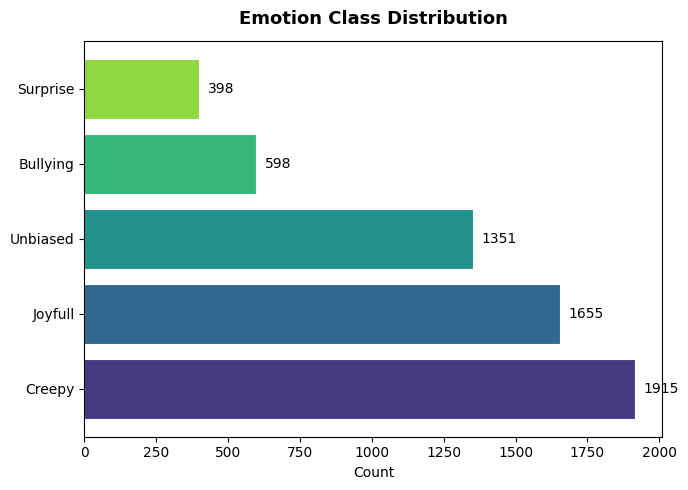

In [23]:
emotion_counts = df['Emotion'].value_counts()
colors_e = sns.color_palette('viridis', len(emotion_counts))

plt.figure(figsize=(7, 5))

plt.barh(emotion_counts.index, emotion_counts.values,
         color=colors_e, edgecolor='white', linewidth=0.8)

plt.title('Emotion Class Distribution', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Count')

for i, v in enumerate(emotion_counts.values):
    plt.text(v + 30, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('emotion_bar_distribution.png', bbox_inches='tight')
plt.show()

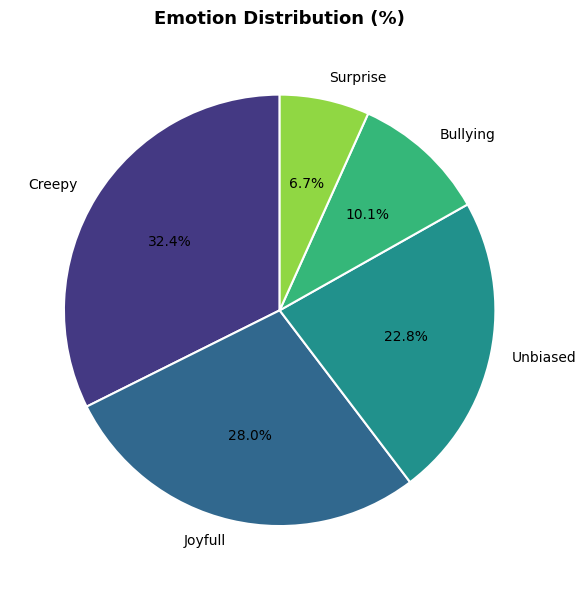

In [24]:
plt.figure(figsize=(19,6))

plt.pie(emotion_counts.values,
        labels=emotion_counts.index,
        autopct='%1.1f%%',
        colors=colors_e,
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})

plt.title('Emotion Distribution (%)', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('emotion_pie_distribution.png', bbox_inches='tight')
plt.show()

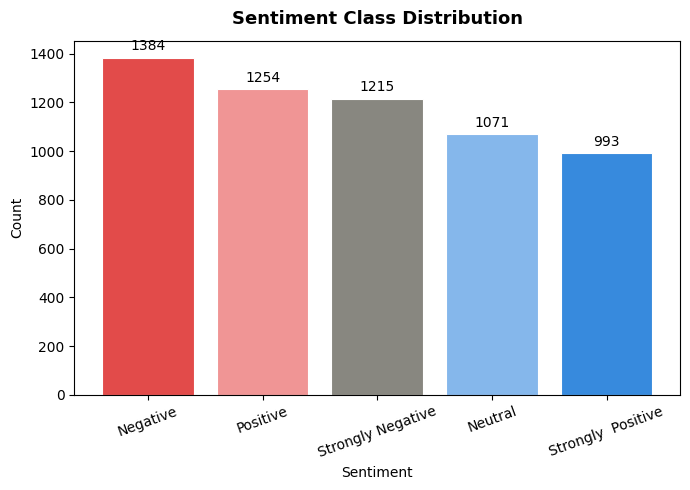

In [25]:
import matplotlib.pyplot as plt

sentiment_counts = df['Sentiment'].value_counts()
colors_s = ['#E24B4A', '#F09595', '#888780', '#85B7EB', '#378ADD']

plt.figure(figsize=(7, 5))

plt.bar(sentiment_counts.index, sentiment_counts.values,
        color=colors_s, edgecolor='white', linewidth=0.8)

plt.title('Sentiment Class Distribution', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=20)

for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 30, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('sentiment_bar_distribution.png', bbox_inches='tight')
plt.show()

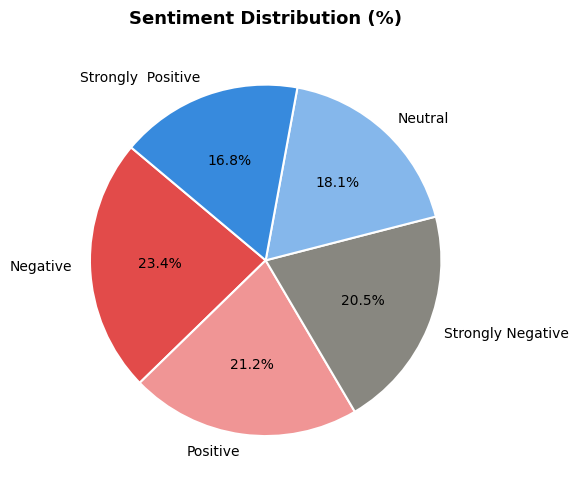

In [26]:
plt.figure(figsize=(7, 5))

plt.pie(sentiment_counts.values,
        labels=sentiment_counts.index,
        autopct='%1.1f%%',
        colors=colors_s,
        startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})

plt.title('Sentiment Distribution (%)', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('sentiment_pie_distribution.png', bbox_inches='tight')
plt.show()

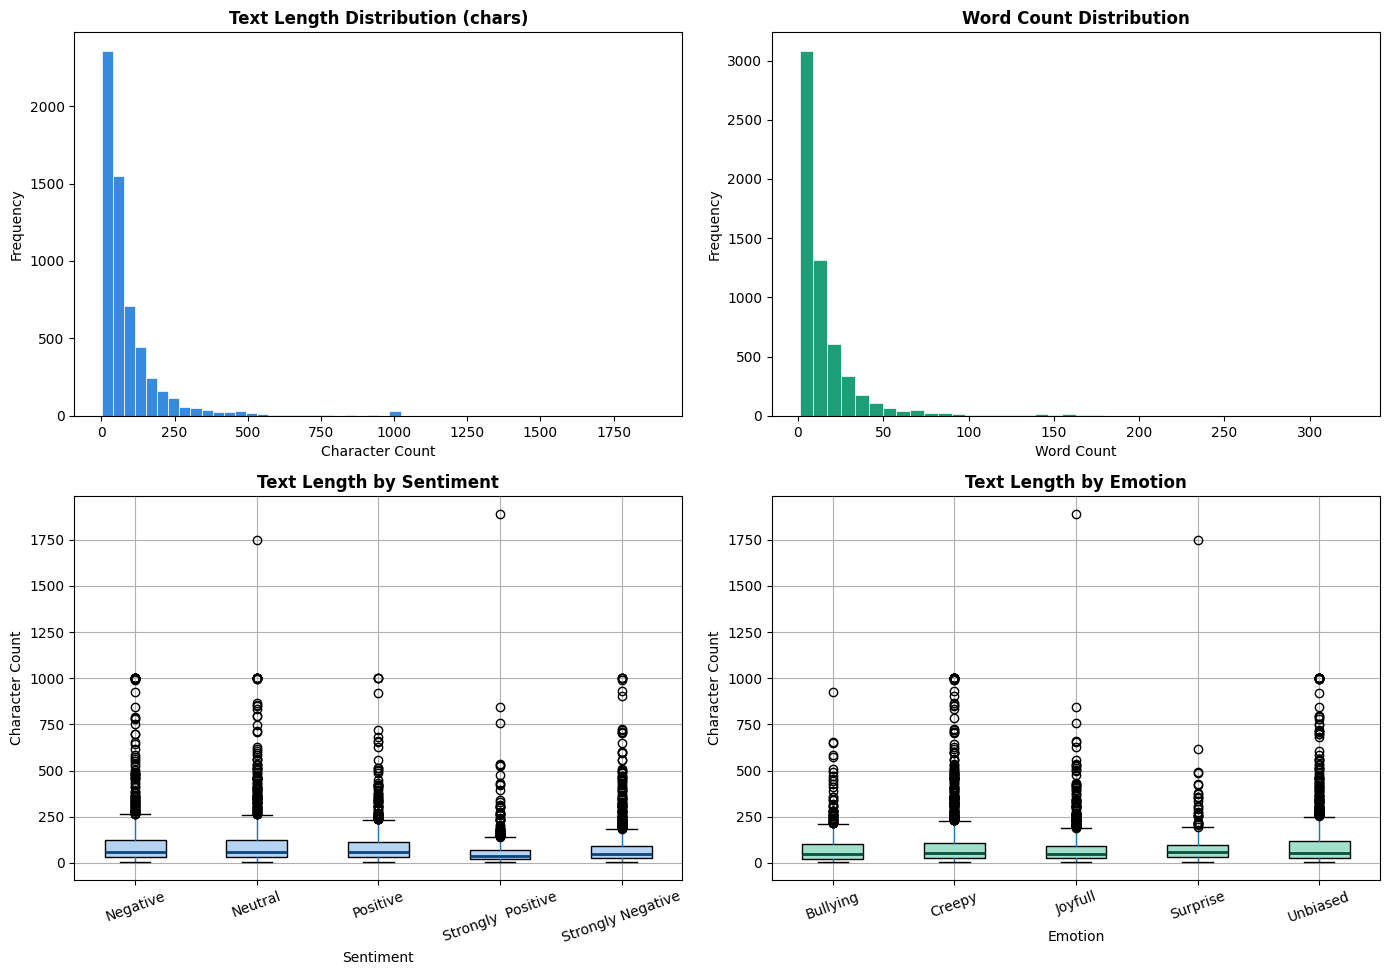


Text Length Stats:
count    5917.0
mean       90.4
std       126.9
min         2.0
25%        26.0
50%        51.0
75%       102.0
max      1891.0
Name: text_length, dtype: float64


In [27]:
df['text_length'] = df['Text'].str.len()
df['word_count'] = df['Text'].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0][0].hist(df['text_length'], bins=50, color='#378ADD', edgecolor='white', linewidth=0.5)
axes[0][0].set_title('Text Length Distribution (chars)', fontsize=12, fontweight='bold')
axes[0][0].set_xlabel('Character Count')
axes[0][0].set_ylabel('Frequency')

axes[0][1].hist(df['word_count'], bins=40, color='#1D9E75', edgecolor='white', linewidth=0.5)
axes[0][1].set_title('Word Count Distribution', fontsize=12, fontweight='bold')
axes[0][1].set_xlabel('Word Count')
axes[0][1].set_ylabel('Frequency')

df.boxplot(column='text_length', by='Sentiment', ax=axes[1][0],
           patch_artist=True, boxprops=dict(facecolor='#B5D4F4'),
           medianprops=dict(color='#0C447C', linewidth=2))
axes[1][0].set_title('Text Length by Sentiment', fontsize=12, fontweight='bold')
axes[1][0].set_xlabel('Sentiment')
axes[1][0].set_ylabel('Character Count')
plt.sca(axes[1][0]); plt.xticks(rotation=20)

df.boxplot(column='text_length', by='Emotion', ax=axes[1][1],
           patch_artist=True, boxprops=dict(facecolor='#9FE1CB'),
           medianprops=dict(color='#085041', linewidth=2))
axes[1][1].set_title('Text Length by Emotion', fontsize=12, fontweight='bold')
axes[1][1].set_xlabel('Emotion')
axes[1][1].set_ylabel('Character Count')
plt.sca(axes[1][1]); plt.xticks(rotation=20)

plt.suptitle('')
plt.tight_layout()
plt.savefig('text_length_analysis.png', bbox_inches='tight')
plt.show()

print("\nText Length Stats:")
print(df['text_length'].describe().round(1))

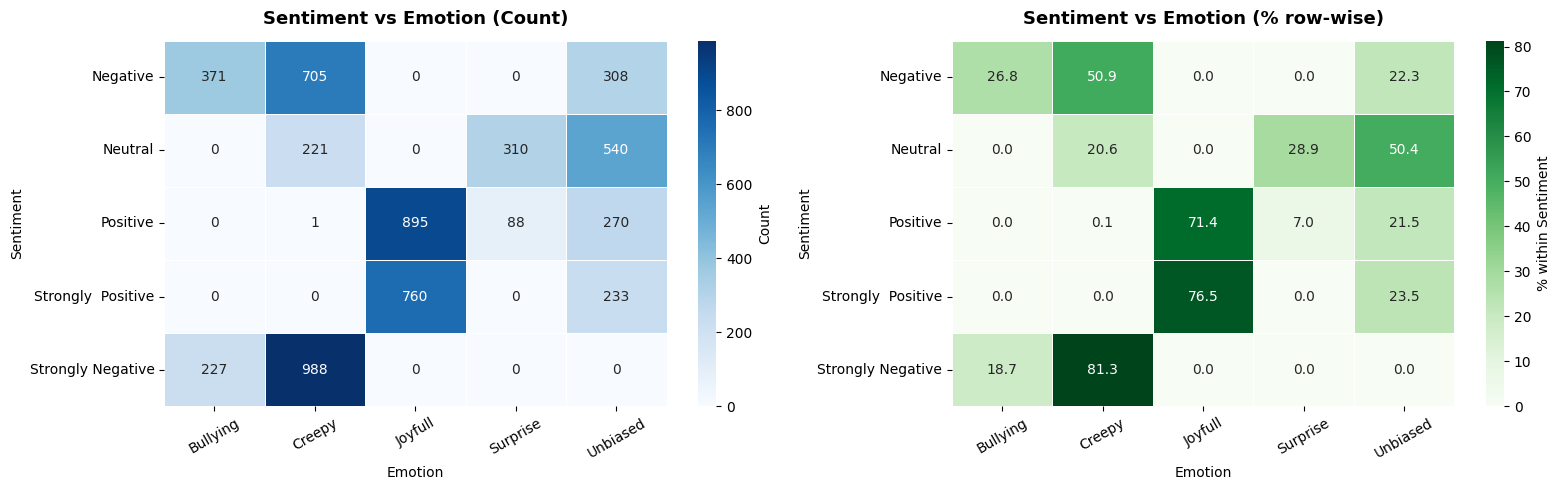

In [28]:
cross_tab = pd.crosstab(df['Sentiment'], df['Emotion'])
cross_pct = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Sentiment vs Emotion (Count)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Sentiment')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(cross_pct.round(1), annot=True, fmt='.1f', cmap='Greens',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': '% within Sentiment'})
axes[1].set_title('Sentiment vs Emotion (% row-wise)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Sentiment')
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('sentiment_emotion_heatmap.png', bbox_inches='tight')
plt.show()

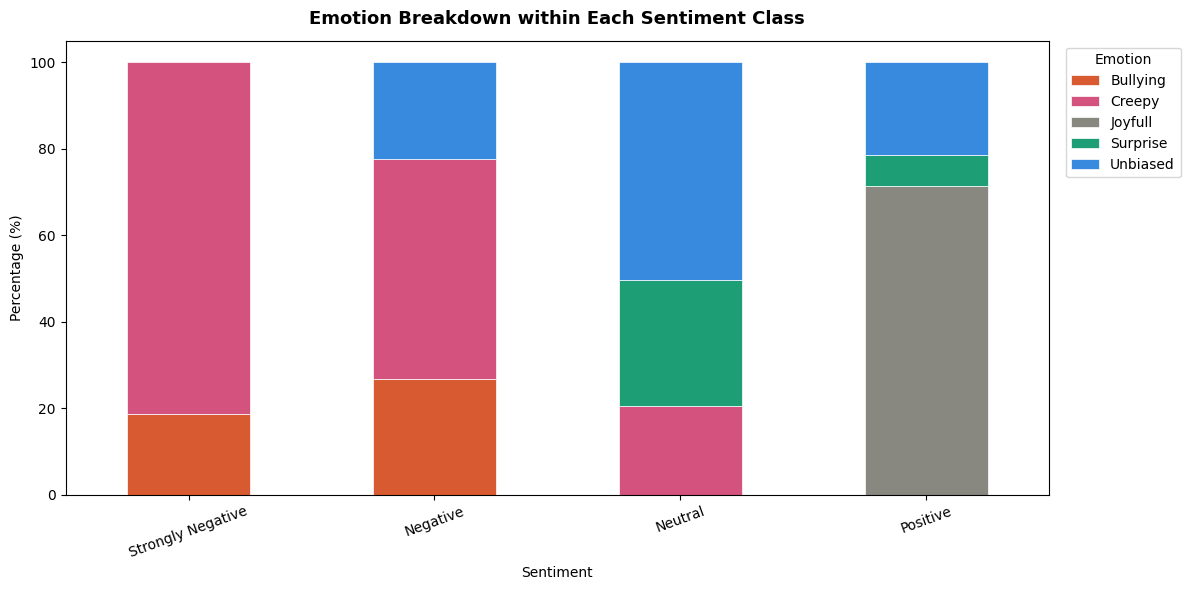

In [29]:
cross_pct = pd.crosstab(df['Sentiment'], df['Emotion'], normalize='index') * 100

sentiment_order = ['Strongly Negative','Negative','Neutral','Positive','Strongly Positive']
cross_pct = cross_pct.reindex([s for s in sentiment_order if s in cross_pct.index])

colors_stack = ['#D85A30','#D4537E','#888780','#1D9E75','#378ADD']
ax = cross_pct.plot(kind='bar', stacked=True, figsize=(12, 6),
                    color=colors_stack, edgecolor='white', linewidth=0.5)
plt.title('Emotion Breakdown within Each Sentiment Class', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Sentiment')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=20)
plt.legend(title='Emotion', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('stacked_bar.png', bbox_inches='tight')
plt.show()

In [30]:
print("." * 55)
print("  FINAL CLEAN DATASET SUMMARY")
print("." * 55)
print(f"  Total samples     : {len(df)}")
print(f"  Columns           : {df.columns.tolist()}")
print(f"  Null values       : {df.isnull().sum().sum()}")
print(f"  Duplicates        : {df.duplicated().sum()}")
print()
print("  Sentiment distribution:")
for k, v in df['Sentiment'].value_counts().items():
    print(f"    {k:<22} : {v}")
print()
print("  Emotion distribution:")
for k, v in df['Emotion'].value_counts().items():
    print(f"    {k:<22} : {v}")
print("." * 55)


.......................................................
  FINAL CLEAN DATASET SUMMARY
.......................................................
  Total samples     : 5917
  Columns           : ['Text', 'Sentiment', 'Emotion', 'text_length', 'word_count']
  Null values       : 0
  Duplicates        : 0

  Sentiment distribution:
    Negative               : 1384
    Positive               : 1254
    Strongly Negative      : 1215
    Neutral                : 1071
    Strongly  Positive     : 993

  Emotion distribution:
    Creepy                 : 1915
    Joyfull                : 1655
    Unbiased               : 1351
    Bullying               : 598
    Surprise               : 398
.......................................................


In [34]:
df.to_csv('Clean Sentiment and Emotion Dataset.csv', index=False)

In [35]:
from google.colab import files
files.download('Clean Sentiment and Emotion Dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
df.head()

,Text,Sentiment,Emotion,text_length,word_count
0,"এসব পাছা কবিরের আজাইররা পোস্ট। হেতি ক, ""যদি ভুল করে থাকি!! "" কত্ত বড় হারামজাদি ইতে!! উষ্ঠা মারা উচিত হেতিরে।",Negative,Creepy,110,20
1,জুতা মারি গরুদান মারান!! আপনার আম্মা আব্বার খেলা দেখে কি সিউর হইছিলেন আপনি তাদেরই মেয়ে???,Strongly Negative,Creepy,89,15
2,"সুখে থাকতে ভুতে কিলাই, প্রবাদটা এর কাজের দ্বারা আবারো প্রমানিত। এর অভিযোগের বাস্তবতা ওরে দিয়েই বাস্তবায়ন করা হোক।",Negative,Bullying,113,18
3,তর মাথায় ব্রেন আছে সেটা তুই দেখছস? না দেখলে ভাব্বি গবর আছে,Strongly Negative,Bullying,58,12
4,আপনি কি নাস্তিক..?,Negative,Unbiased,18,3
